In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.chdir('/content/drive/MyDrive/Data-Driven-Energy-Project')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [9]:
df = pd.read_csv("data/energy_efficiency.csv")
df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    float64
 6   X7      768 non-null    float64
 7   X8      768 non-null    float64
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(10)
memory usage: 101.4 KB


In [11]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [12]:
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]

In [13]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28


In [14]:
df.isnull().sum()

,0
Relative_Compactness,528
Surface_Area,528
Wall_Area,528
Roof_Area,528
Height,528
Orientation,528
Glazing_Area,528
Glazing_Distribution,528
Heating_Load,528
Cooling_Load,528


In [15]:
os.makedirs("outputs/graphs", exist_ok=True)

**CORRELATION HEATMAP**

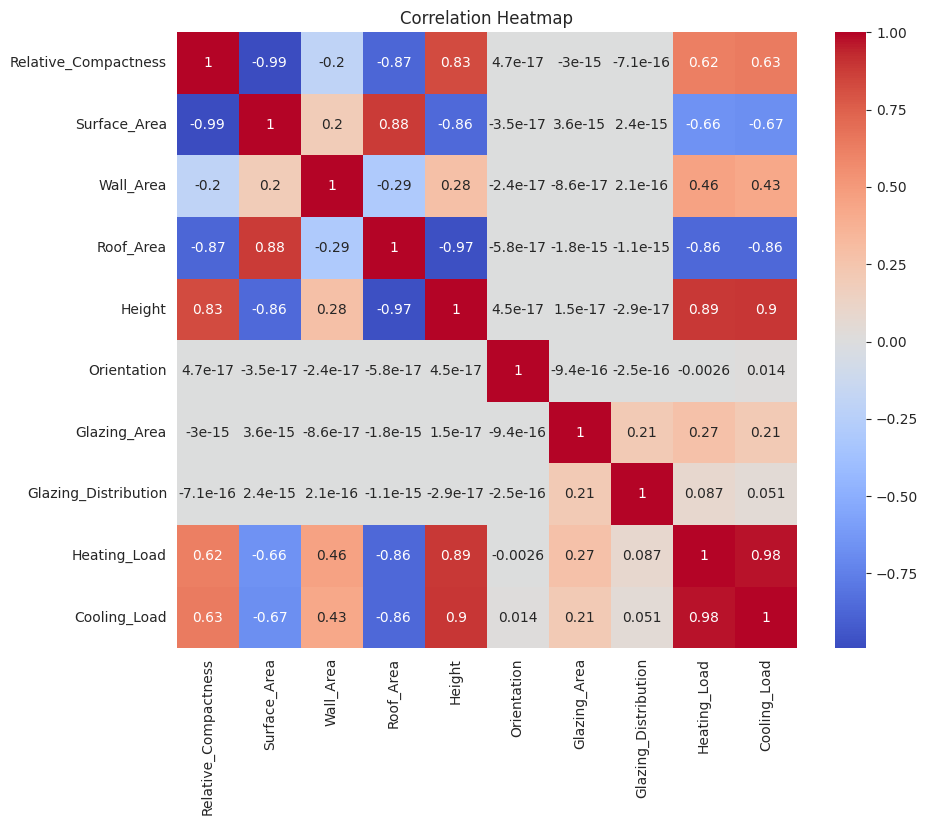

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.savefig("outputs/graphs/01_heatmap.png")
plt.show()

Heating and Cooling loads are strongly correlated

Surface Area and Wall Area show strong relationships

Relative Compactness has negative correlation with energy

**HEATING LOAD DISTRIBUTION**

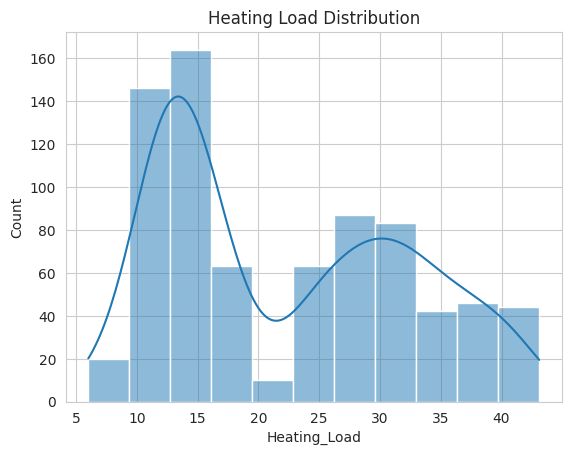

In [17]:
sns.histplot(df["Heating_Load"], kde=True)
plt.title("Heating Load Distribution")

plt.savefig("outputs/graphs/02_heating_distribution.png")
plt.show()

**COOLING LOAD DISTRIBUTION**

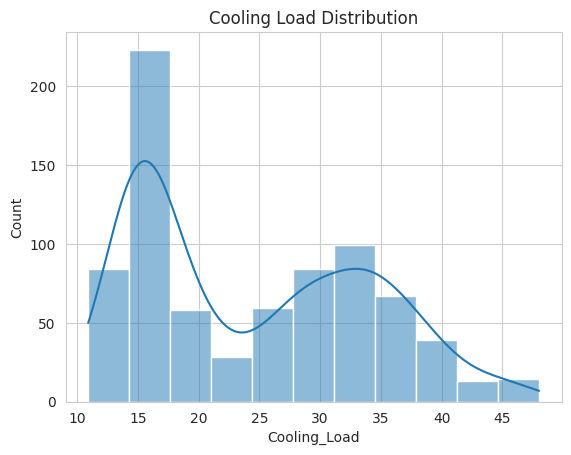

In [18]:
sns.histplot(df["Cooling_Load"], kde=True)
plt.title("Cooling Load Distribution")

plt.savefig("outputs/graphs/03_cooling_distribution.png")
plt.show()

**SCATTER PLOT**

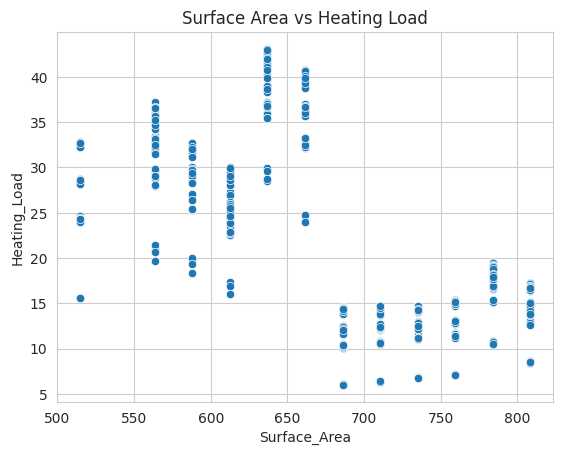

In [19]:
sns.scatterplot(x="Surface_Area", y="Heating_Load", data=df)
plt.title("Surface Area vs Heating Load")

plt.savefig("outputs/graphs/04_surface_vs_heating.png")
plt.show()

**PAIRPLOT**

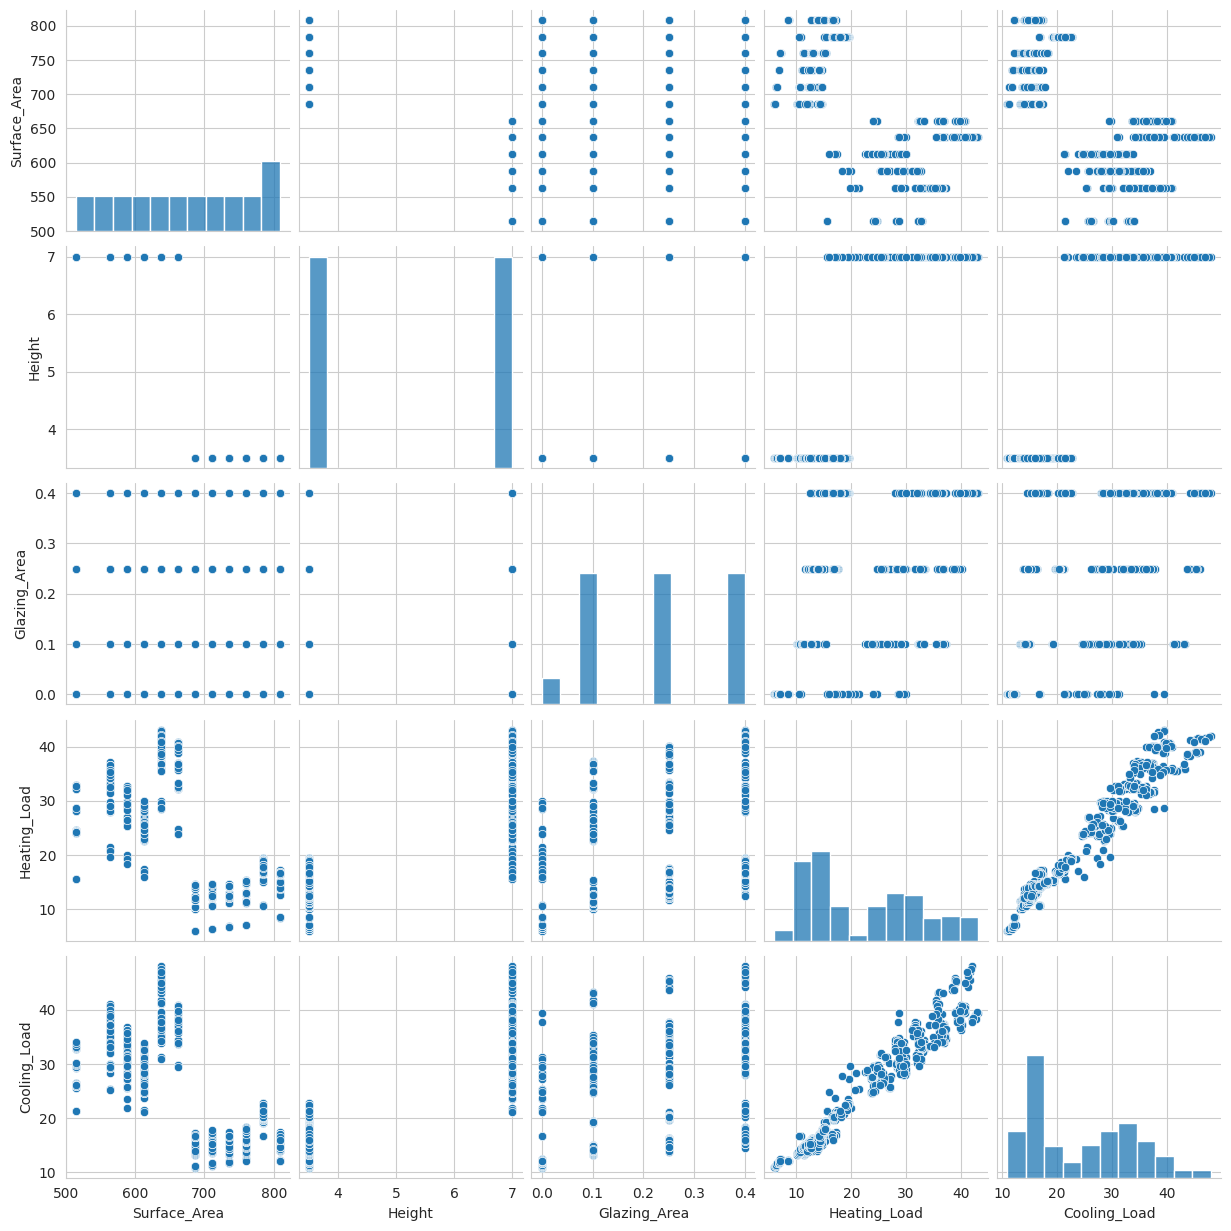

In [20]:
sns.pairplot(df[[
    "Surface_Area",
    "Height",
    "Glazing_Area",
    "Heating_Load",
    "Cooling_Load"
]])

plt.savefig("outputs/graphs/05_pairplot.png")
plt.show()

**HISTOGRAMS FOR ALL FEATURES**

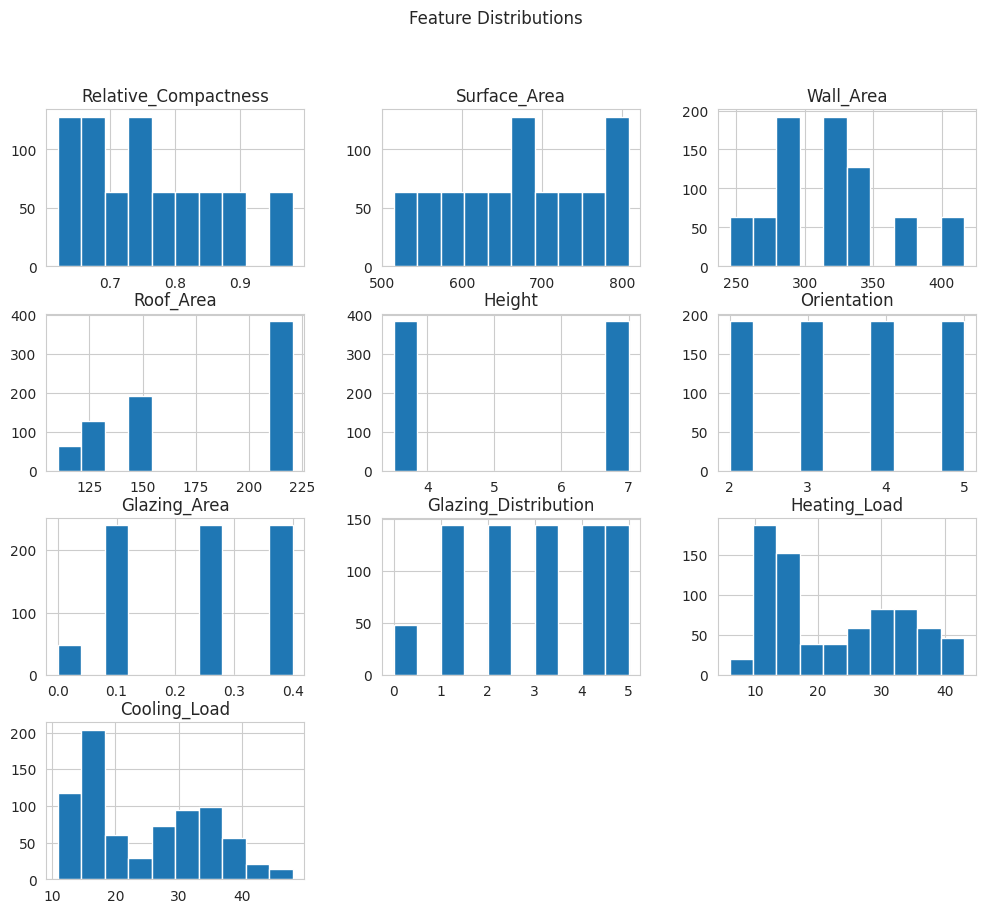

In [37]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.savefig("outputs/graphs/06_feature_distributions.png")
plt.show()

**BOXPLOT— FEATURES vs HEATING LOAD**

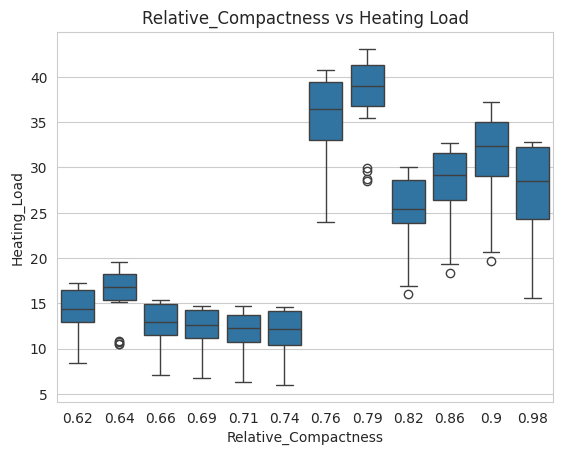

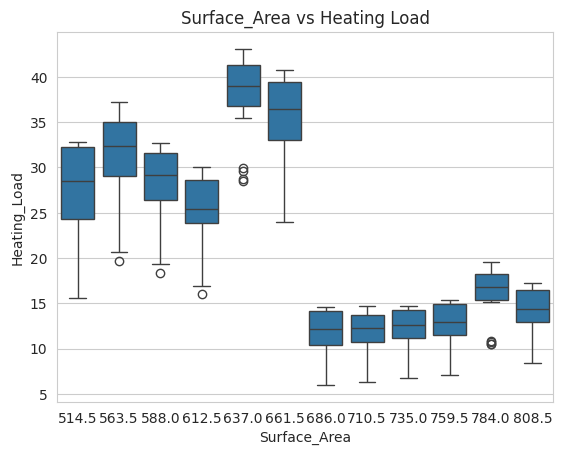

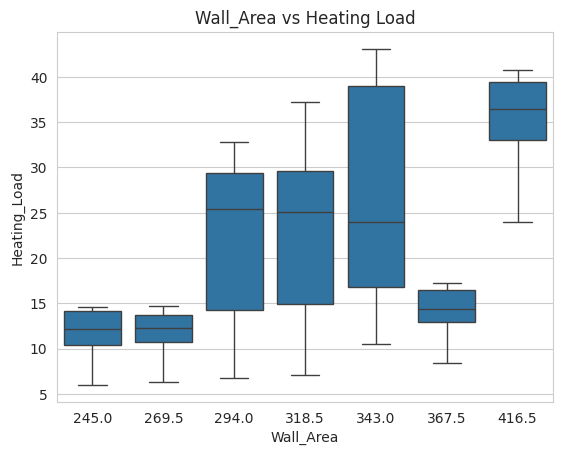

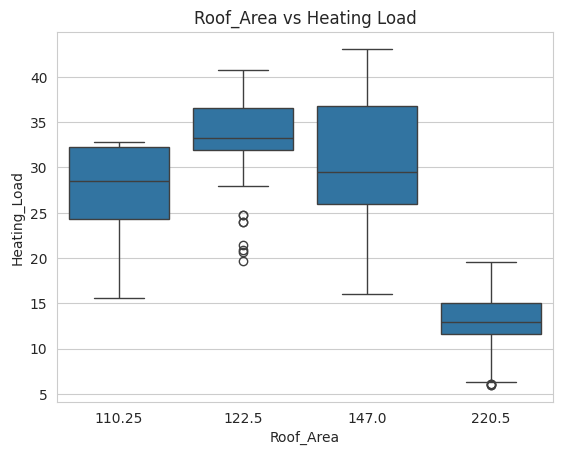

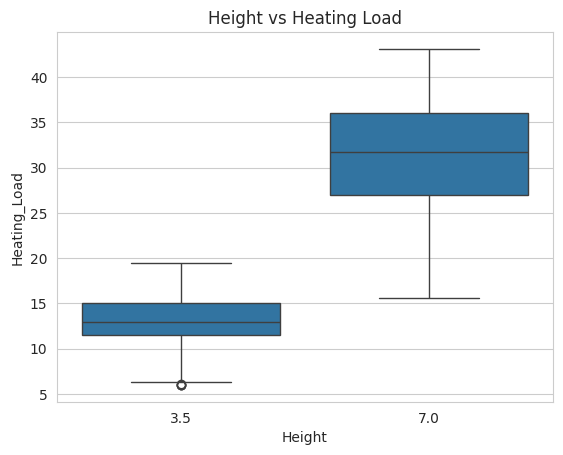

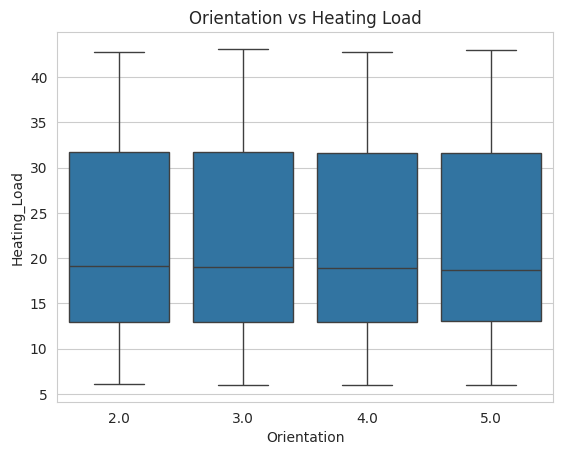

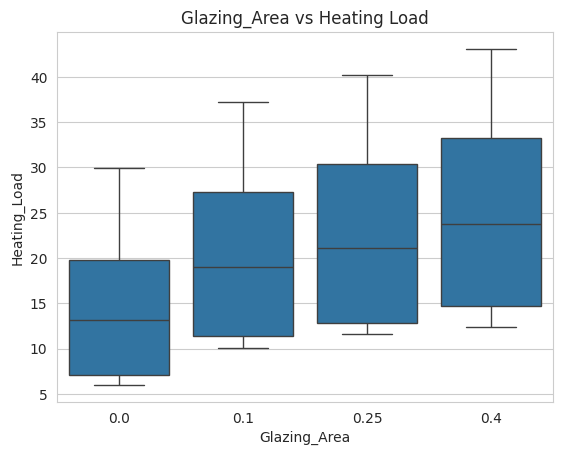

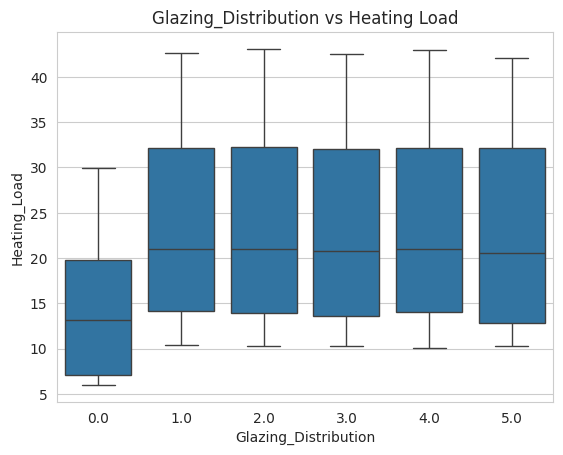

In [38]:
for col in df.columns[:-2]:
    plt.figure()
    sns.boxplot(x=df[col], y=df["Heating_Load"])
    plt.title(f"{col} vs Heating Load")
    plt.savefig(f"outputs/graphs/heating_{col}.png")
    plt.show()

**BOXPLOT — FEATURES vs COOLING LOAD**

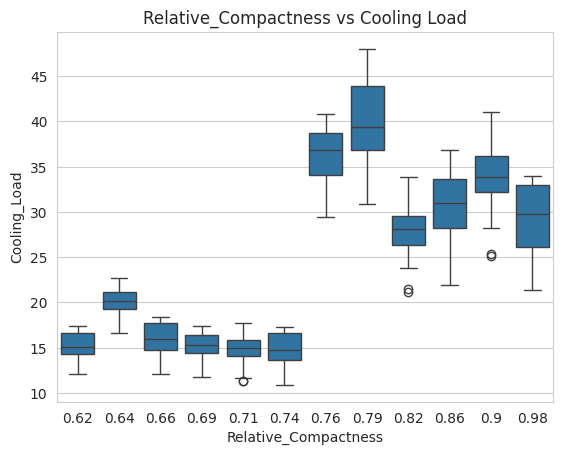

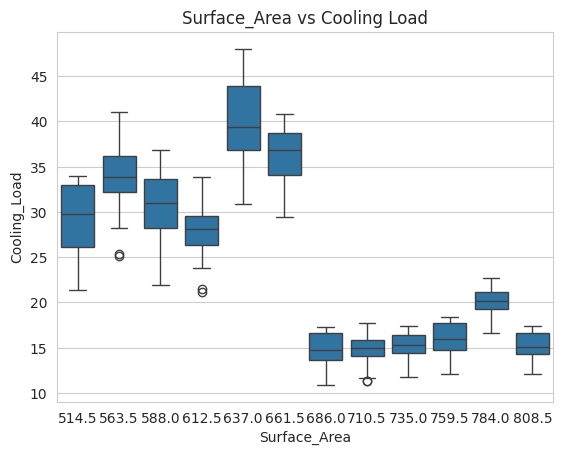

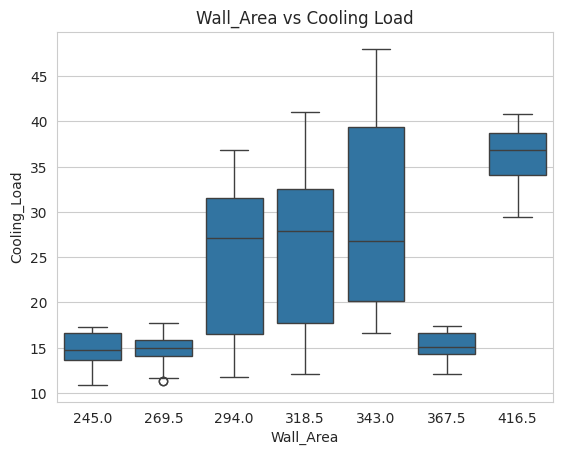

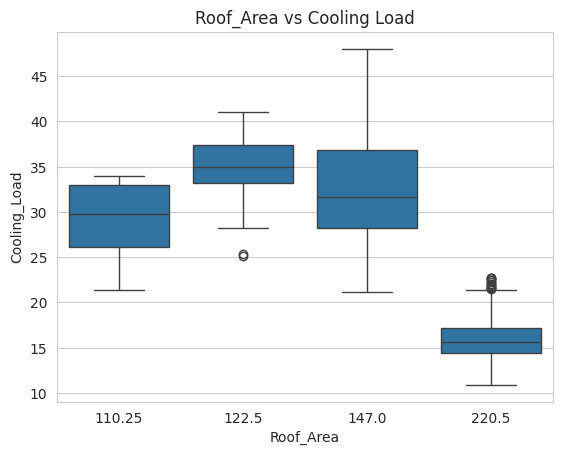

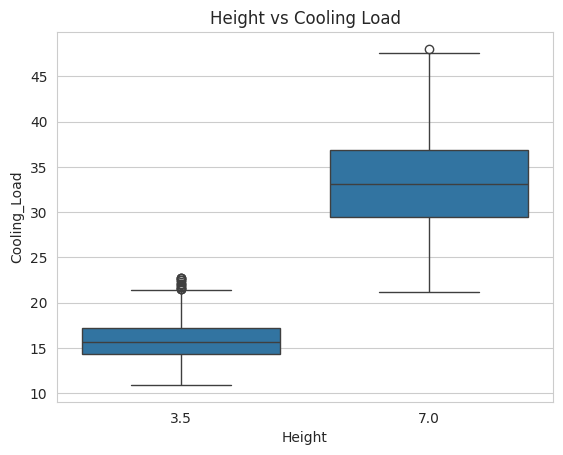

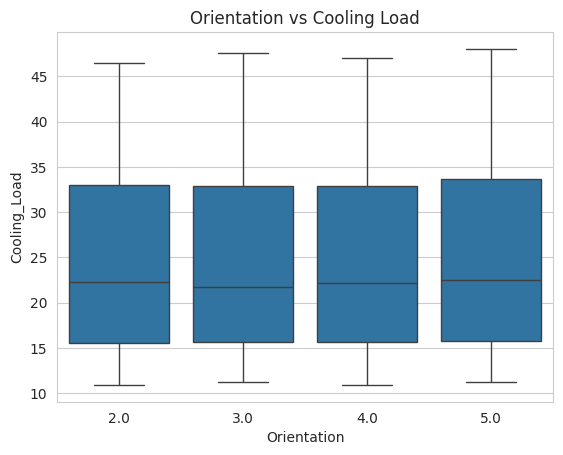

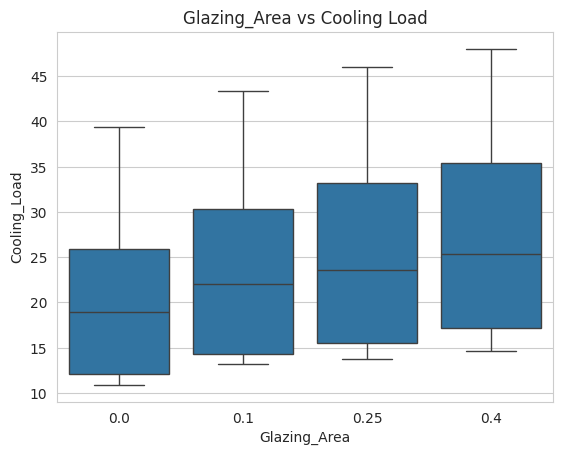

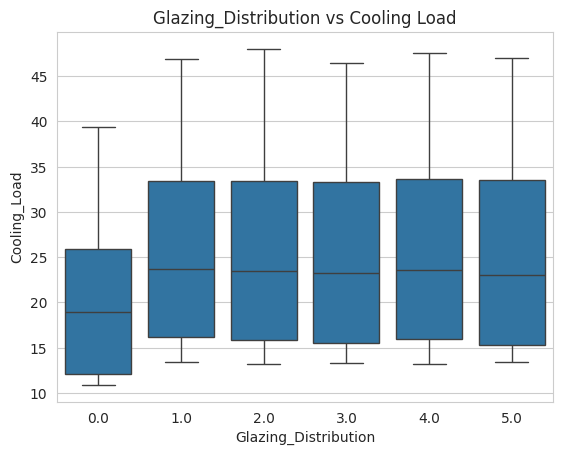

In [39]:
for col in df.columns[:-2]:
    plt.figure()
    sns.boxplot(x=df[col], y=df["Cooling_Load"])
    plt.title(f"{col} vs Cooling Load")
    plt.savefig(f"outputs/graphs/cooling_{col}.png")
    plt.show()

**OBSERVATIONS:**

The dataset contains 768 samples with no missing values. Correlation analysis reveals a strong relationship between heating and cooling loads. Surface area and glazing area significantly influence energy consumption. The distribution of the target variables indicates suitability for regression modeling.

Most features show clear influence on Heating and Cooling loads.

Glazing Area significantly impacts Cooling Load.

Relative Compactness shows inverse relation with energy usage.

Some features show clustered distributions indicating structured data